# Capstone Project: Predicting US Traffic Accident Severity

**MDS Data Science Masters — Group 17**  
**Authors:** Osvaldo Rivera, Nitin Nellisserry  

---

## 1. Problem Statement

This project aims to **predict traffic accident severity** using the US Accidents dataset. We frame the task as a **binary classification** problem:

- **Target:** `High_Severity` — whether an accident is high severity (Severity 3 or 4) or not (Severity 1 or 2).
- **Features:** Weather (temperature, humidity, visibility, precipitation, wind speed), road infrastructure (traffic signal, junction, crossing), time (hour, day of week, weekend), weather condition (one-hot), and state (one-hot).

**Goal:** Build and compare classification models to identify factors associated with high-severity accidents and provide a usable predictive model for potential deployment in traffic safety applications.

## 2. Setup and Data Loading (Build Cleaned Dataset from Raw)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
    accuracy_score,
    f1_score,
    make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
%matplotlib inline

In [25]:
RAW_PATH = "datasets/US_Accidents_March23.csv"
SAMPLE_SIZE = 120_000
RANDOM_STATE = 42

# 1) Load raw and sample
df = pd.read_csv(RAW_PATH)
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

# 2) Select columns
selected_cols = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Weather_Condition", "Precipitation(in)",
    "Wind_Speed(mph)", "Traffic_Signal", "Junction", "Crossing", "State"
]
df = df[selected_cols].copy()

# 3) Parse datetime and engineer time features
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")
df = df.dropna(subset=["Start_Time"]).copy()
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# 4) Binary target
df["High_Severity"] = (df["Severity"] >= 3).astype(int)

# 5) Handle missing values
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)
df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

# 6) One-hot encode and drop Start_Time
df = df.drop(columns=["Start_Time"])
df = pd.get_dummies(df, columns=["Weather_Condition", "State"], drop_first=True)

# 7) Engineered features for modeling
df["RushHour"] = (((df["Hour"] >= 7) & (df["Hour"] <= 9)) | ((df["Hour"] >= 16) & (df["Hour"] <= 19))).astype(int)
df["Low_Visibility"] = (df["Visibility(mi)"] < 3).astype(int)
df["Precipitation_log"] = np.log1p(df["Precipitation(in)"])

# Optional: save for reuse (comment out if you prefer in-memory only)
df.to_csv("datasets/cleaned_accidents.csv", index=False)

print("Shape:", df.shape)
df.head()

Shape: (120000, 143)


,Severity,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,Hour,DayOfWeek,Is_Weekend,High_Severity,Weather_Condition_Blowing Dust / Windy,Weather_Condition_Blowing Snow,Weather_Condition_Blowing Snow / Windy,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Cloudy / Windy,Weather_Condition_Drizzle,...,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,RushHour,Low_Visibility,Precipitation_log
7133276,1,78.0,81.0,10.0,0.01,13.0,True,False,False,9,4,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.00995
5363845,2,55.0,88.0,10.0,0.00,9.0,False,False,True,10,3,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,0.00000
155993,3,91.0,47.0,10.0,0.00,10.4,False,False,True,16,4,0,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.00000
1861414,3,67.0,84.0,10.0,0.00,3.0,False,False,False,15,4,0,1,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,0,0,0.00000
2021359,2,95.0,16.0,10.0,0.00,6.0,False,False,False,16,0,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.00000


## 3. Exploratory Data Analysis

In [26]:
# Basic overview
print(df.info())
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 7133276 to 5656635
Columns: 143 entries, Severity to Precipitation_log
dtypes: bool(130), float64(6), int32(2), int64(5)
memory usage: 26.8 MB
None

Missing values:
None


High_Severity distribution:
High_Severity
0    0.8047
1    0.1953
Name: proportion, dtype: float64


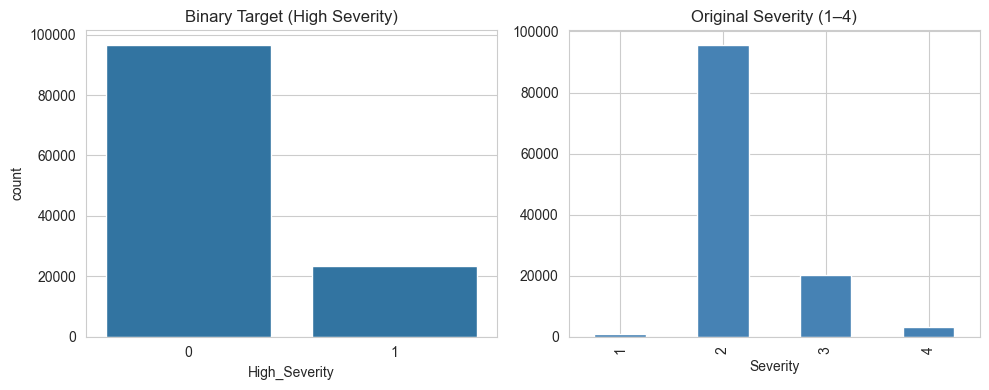

In [27]:
# Target distribution
print("High_Severity distribution:")
print(df["High_Severity"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="High_Severity", data=df, ax=axes[0])
axes[0].set_title("Binary Target (High Severity)")
df["Severity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Original Severity (1–4)")
axes[1].set_xlabel("Severity")
plt.tight_layout()
plt.show()

In [28]:
# Numeric feature summaries
numeric_cols = ["Temperature(F)", "Humidity(%)", "Visibility(mi)", "Precipitation(in)", "Wind_Speed(mph)", "Hour", "DayOfWeek", "Is_Weekend"]
numeric_present = [c for c in numeric_cols if c in df.columns]
if numeric_present:
    print(df[numeric_present].describe())

       Temperature(F)    Humidity(%)  Visibility(mi)  Precipitation(in)  Wind_Speed(mph)           Hour      DayOfWeek     Is_Weekend
count   120000.000000  120000.000000   120000.000000      120000.000000    120000.000000  120000.000000  120000.000000  120000.000000
mean        61.636560      64.881375        9.111385           0.005843         7.626853      12.342550       2.605600       0.161508
std         18.867676      22.535065        2.643636           0.085562         5.634831       5.479414       1.809561       0.368001
min        -89.000000       2.000000        0.000000           0.000000         0.000000       0.000000       0.000000       0.000000
25%         50.000000      49.000000       10.000000           0.000000         5.000000       8.000000       1.000000       0.000000
50%         64.000000      67.000000       10.000000           0.000000         7.000000      13.000000       3.000000       0.000000
75%         75.900000      84.000000       10.000000          

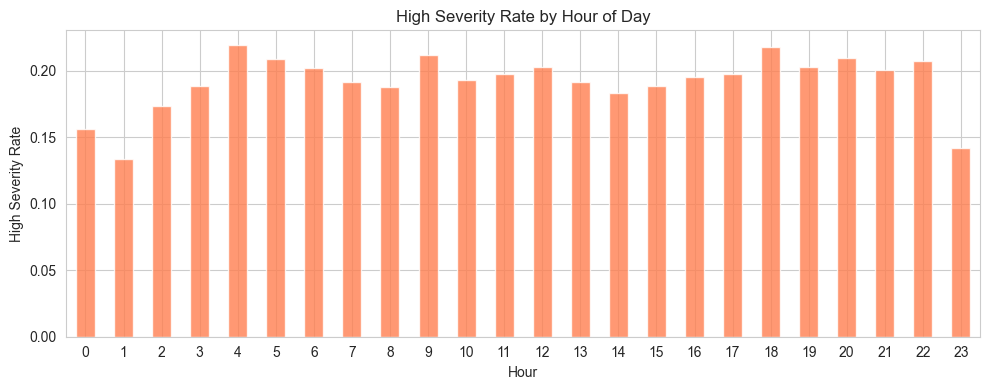

In [29]:
# High severity rate by hour
if "Hour" in df.columns:
    hr_rate = df.groupby("Hour")["High_Severity"].mean()
    plt.figure(figsize=(10, 4))
    hr_rate.plot(kind="bar", color="coral", alpha=0.8)
    plt.title("High Severity Rate by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("High Severity Rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

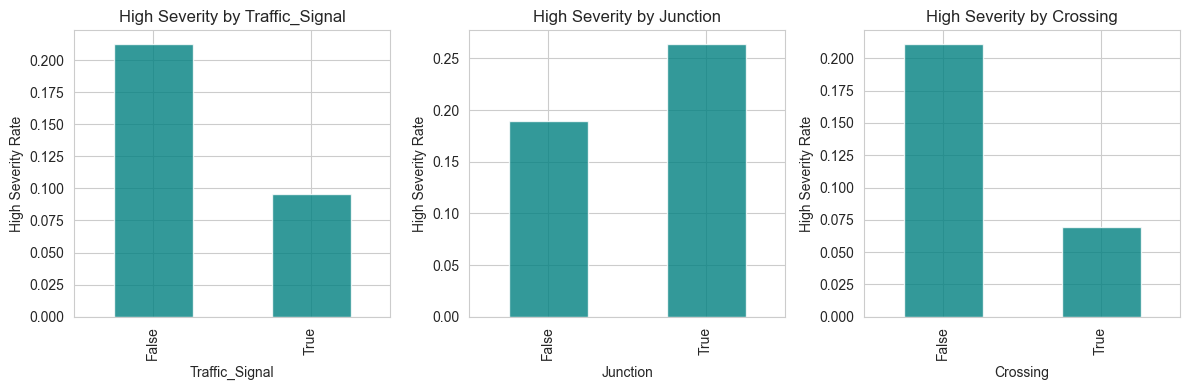

In [30]:
# Infrastructure flags vs high severity
infra = ["Traffic_Signal", "Junction", "Crossing"]
infra_present = [c for c in infra if c in df.columns]
if infra_present:
    fig, axes = plt.subplots(1, len(infra_present), figsize=(4 * len(infra_present), 4))
    if len(infra_present) == 1:
        axes = [axes]
    for ax, col in zip(axes, infra_present):
        df.groupby(col)["High_Severity"].mean().plot(kind="bar", ax=ax, color="teal", alpha=0.8)
        ax.set_title(f"High Severity by {col}")
        ax.set_ylabel("High Severity Rate")
    plt.tight_layout()
    plt.show()

## 4. Train/Test Split and Feature Matrix

In [31]:
# Target
y = df["High_Severity"].copy()

# Features: drop ID-like and target columns
drop_cols = ["Severity", "High_Severity"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Keep numeric and boolean columns (cleaned data has one-hot and flags)
X = X.select_dtypes(include=[np.number, 'bool'])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", len(X_train), "Test size:", len(X_test))

Feature matrix shape: (120000, 141)
Target shape: (120000,)
Train size: 90000 Test size: 30000


In [32]:
# Clip numeric features to 1st–99th percentile (using train stats) to reduce outlier impact
X_train = X_train.copy()
X_test = X_test.copy()
num_cols = X_train.select_dtypes(include=[np.number]).columns
for c in num_cols:
    low, high = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(low, high)
    X_test[c] = X_test[c].clip(low, high)
print("Outlier clipping applied (train percentiles).")

Outlier clipping applied (train percentiles).


In [33]:
# Feature scaling (fit on train, transform train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled feature shapes:", X_train_scaled.shape, X_test_scaled.shape)

Scaled feature shapes: (90000, 141) (30000, 141)


## 5. Modeling

In [34]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Print classification report, confusion matrix, and optionally ROC-AUC."""
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print("="*60)
    # Support: per-class = # samples in that class; accuracy/macro/weighted rows = total # samples (test set size)
    print(classification_report(y_true, y_pred, target_names=["Low", "High"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    auc = None
    if y_proba is not None and len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC: {auc:.4f}")
    p_high, r_high, f1_high, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)
    p_low, r_low, f1_low, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=0)
    return {"accuracy": acc, "roc_auc": auc,
            "precision_high": p_high, "recall_high": r_high, "f1_high": f1_high,
            "precision_low": p_low, "recall_low": r_low, "f1_low": f1_low,
            "predictions": y_pred, "probabilities": y_proba}

In [35]:
# Logistic Regression (baseline) — no hyperparameter tuning
lr_simple = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_simple.fit(X_train_scaled, y_train)
y_pred_lr_simple = lr_simple.predict(X_test_scaled)
y_proba_lr_simple = lr_simple.predict_proba(X_test_scaled)[:, 1]
results_lr_simple = evaluate_model("Logistic Regression (baseline)", y_test, y_pred_lr_simple, y_proba_lr_simple)


Model: Logistic Regression (baseline)
              precision    recall  f1-score   support

         Low       0.89      0.69      0.77     24141
        High       0.33      0.64      0.44      5859

    accuracy                           0.68     30000
   macro avg       0.61      0.66      0.60     30000
weighted avg       0.78      0.68      0.71     30000

Confusion Matrix:
[[16563  7578]
 [ 2122  3737]]
Accuracy: 0.6767
ROC-AUC: 0.7192


### Interpretation

- **Support column:** In the classification report, "support" is the number of samples: each class row (Low, High) shows how many test samples are in that class; the accuracy/macro avg/weighted avg rows show the **total** test set size (e.g. 30000), so those three rows all show the same number.
- **Models:** Logistic Regression (baseline) is compared with RF, XGBoost, DNN, and Stacking; tree-based and stacked models often improve on ROC-AUC and F1 (High).
- **Imbalance:** The data is ~80% Low, ~20% High. Models tuned for F1 (High) predict more Highs to catch high-severity cases. For identifying high-severity accidents, **F1 (High)** and **ROC-AUC** are the main metrics.
- **LR vs RF/XGBoost:** Random Forest and XGBoost often outperform the Logistic Regression (baseline) (especially on ROC-AUC). The gains are modest because the problem is inherently difficult and we use limited tuning.
- **Why performance is modest:** Severity is influenced by many unmeasured factors; we use a subset of features and limited tuning. This is normal for a first pass.
- **Conclusion:** The pipeline works: ensemble and tree-based models can improve on the Logistic Regression (baseline) for ROC-AUC and F1 (High). To improve further, add more tuning, features, or resampling.

In [ ]:
f1_scorer = make_scorer(f1_score, pos_label=1)

In [37]:
# Random Forest with hyperparameter tuning (F1) on scaled data
rf_param_grid = {"n_estimators": [80, 120, 150], "max_depth": [12, 15, 20], "min_samples_leaf": [2, 4, 6]}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1), param_distributions=rf_param_grid, n_iter=3, scoring=f1_scorer, cv=2, random_state=42, n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)
rf = rf_search.best_estimator_
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
print("Best RF params:", rf_search.best_params_)


Model: Random Forest
              precision    recall  f1-score   support

         Low       0.89      0.68      0.77     24141
        High       0.33      0.64      0.43      5859

    accuracy                           0.67     30000
   macro avg       0.61      0.66      0.60     30000
weighted avg       0.78      0.67      0.70     30000

Confusion Matrix:
[[16419  7722]
 [ 2091  3768]]
Accuracy: 0.6729
ROC-AUC: 0.7242
Best RF params: {'n_estimators': 120, 'min_samples_leaf': 4, 'max_depth': 15}


In [38]:
# XGBoost with hyperparameter tuning (F1) on scaled data
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_param_grid = {"n_estimators": [80, 120, 150], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1, 0.15], "min_child_weight": [1, 3, 5]}
xgb_search = RandomizedSearchCV(xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos), param_distributions=xgb_param_grid, n_iter=3, scoring=f1_scorer, cv=2, random_state=42, n_jobs=-1)
xgb_search.fit(X_train_scaled, y_train)
xgb_clf = xgb_search.best_estimator_
y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
print("Best XGB params:", xgb_search.best_params_)


Model: XGBoost
              precision    recall  f1-score   support

         Low       0.89      0.69      0.78     24141
        High       0.34      0.65      0.44      5859

    accuracy                           0.68     30000
   macro avg       0.61      0.67      0.61     30000
weighted avg       0.78      0.68      0.71     30000

Confusion Matrix:
[[16639  7502]
 [ 2068  3791]]
Accuracy: 0.6810
ROC-AUC: 0.7355
Best XGB params: {'n_estimators': 120, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05}


In [39]:
# DNN (MLP) on scaled data with class weights for imbalance
keras.utils.set_random_seed(42)
n_features = X_train_scaled.shape[1]
class_weight = {0: 1.0, 1: (y_train == 0).sum() / max((y_train == 1).sum(), 1)}
dnn = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(n_features,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])
dnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
dnn.fit(X_train_scaled, y_train, epochs=10, batch_size=512, class_weight=class_weight, validation_split=0.1, verbose=0)
y_proba_dnn = dnn.predict(X_test_scaled, verbose=0).ravel()
y_pred_dnn = (y_proba_dnn >= 0.5).astype(int)
results_dnn = evaluate_model("DNN", y_test, y_pred_dnn, y_proba_dnn)

c:\Users\nitin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model: DNN
              precision    recall  f1-score   support

         Low       0.89      0.67      0.76     24141
        High       0.33      0.67      0.44      5859

    accuracy                           0.67     30000
   macro avg       0.61      0.67      0.60     30000
weighted avg       0.78      0.67      0.70     30000

Confusion Matrix:
[[16086  8055]
 [ 1944  3915]]
Accuracy: 0.6667
ROC-AUC: 0.7301


In [40]:
# Wrapper so Keras DNN can be used in StackingClassifier (fit/predict/predict_proba)
class KerasClassifierWrapper:
    def __init__(self, epochs=10, batch_size=512, random_state=42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model_ = None

    def fit(self, X, y):
        keras.utils.set_random_seed(self.random_state)
        n_features = X.shape[1]
        cw = {0: 1.0, 1: (y == 0).sum() / max((y == 1).sum(), 1)}
        self.model_ = keras.Sequential([
            layers.Dense(64, activation="relu", input_shape=(n_features,)),
            layers.Dropout(0.3),
            layers.Dense(32, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(1, activation="sigmoid"),
        ])
        self.model_.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, class_weight=cw, validation_split=0.1, verbose=0)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        p = self.model_.predict(X, verbose=0).ravel()
        return (p >= 0.5).astype(int)

    def predict_proba(self, X):
        p = self.model_.predict(X, verbose=0).ravel()
        return np.column_stack([1 - p, p])

    def get_params(self, deep=True):
        return {"epochs": self.epochs, "batch_size": self.batch_size, "random_state": self.random_state}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

dnn_estimator = KerasClassifierWrapper(epochs=10, batch_size=512, random_state=42)

In [41]:
# Stacking ensemble: LR + RF + XGBoost + DNN with logistic regression meta-learner
stack = StackingClassifier(
    estimators=[
        ("lr", lr_simple),
        ("rf", rf),
        ("xgb", xgb_clf),
        ("dnn", dnn_estimator),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    cv=3,
)
stack.fit(X_train_scaled, y_train)
y_pred_stack = stack.predict(X_test_scaled)
y_proba_stack = stack.predict_proba(X_test_scaled)[:, 1]
results_stack = evaluate_model("Stacking (LR+RF+XGB+DNN)", y_test, y_pred_stack, y_proba_stack)

c:\Users\nitin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\nitin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model: Stacking (LR+RF+XGB+DNN)
              precision    recall  f1-score   support

         Low       0.89      0.67      0.77     24141
        High       0.33      0.67      0.45      5859

    accuracy                           0.67     30000
   macro avg       0.61      0.67      0.61     30000
weighted avg       0.78      0.67      0.71     30000

Confusion Matrix:
[[16257  7884]
 [ 1916  3943]]
Accuracy: 0.6733
ROC-AUC: 0.7377


## 6. Model Comparison

In [42]:
# Summary table (all models)
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest", "XGBoost", "DNN", "Stacking (LR+RF+XGB+DNN)"],
    "Accuracy": [results_lr_simple["accuracy"], results_rf["accuracy"], results_xgb["accuracy"], results_dnn["accuracy"], results_stack["accuracy"]],
    "ROC-AUC": [
        results_lr_simple.get("roc_auc") or (roc_auc_score(y_test, results_lr_simple["probabilities"]) if results_lr_simple.get("probabilities") is not None else 0.5),
        results_rf.get("roc_auc") or roc_auc_score(y_test, results_rf["probabilities"]),
        results_xgb.get("roc_auc") or roc_auc_score(y_test, results_xgb["probabilities"]),
        results_dnn.get("roc_auc") or roc_auc_score(y_test, results_dnn["probabilities"]),
        results_stack.get("roc_auc") or roc_auc_score(y_test, results_stack["probabilities"])
    ],
    "Precision (Low)": [results_lr_simple.get("precision_low", 0), results_rf.get("precision_low", 0), results_xgb.get("precision_low", 0), results_dnn.get("precision_low", 0), results_stack.get("precision_low", 0)],
    "Recall (Low)": [results_lr_simple.get("recall_low", 0), results_rf.get("recall_low", 0), results_xgb.get("recall_low", 0), results_dnn.get("recall_low", 0), results_stack.get("recall_low", 0)],
    "F1 (Low)": [results_lr_simple.get("f1_low", 0), results_rf.get("f1_low", 0), results_xgb.get("f1_low", 0), results_dnn.get("f1_low", 0), results_stack.get("f1_low", 0)],
    "Precision (High)": [results_lr_simple.get("precision_high", 0), results_rf.get("precision_high", 0), results_xgb.get("precision_high", 0), results_dnn.get("precision_high", 0), results_stack.get("precision_high", 0)],
    "Recall (High)": [results_lr_simple.get("recall_high", 0), results_rf.get("recall_high", 0), results_xgb.get("recall_high", 0), results_dnn.get("recall_high", 0), results_stack.get("recall_high", 0)],
    "F1 (High)": [results_lr_simple.get("f1_high", 0), results_rf.get("f1_high", 0), results_xgb.get("f1_high", 0), results_dnn.get("f1_high", 0), results_stack.get("f1_high", 0)]
})
print(comparison.to_string(index=False))

                         Model  Accuracy  ROC-AUC  Precision (Low)  Recall (Low)  F1 (Low)  Precision (High)  Recall (High)  F1 (High)
Logistic Regression (baseline)  0.676667 0.719248         0.886433      0.686094  0.773502          0.330270       0.637822   0.435193
                 Random Forest  0.672900 0.724193         0.887034      0.680129  0.769923          0.327937       0.643113   0.434377
                       XGBoost  0.681000 0.735516         0.889453      0.689242  0.776652          0.335695       0.647039   0.442048
                           DNN  0.666700 0.730051         0.892180      0.666335  0.762894          0.327068       0.668203   0.439172
      Stacking (LR+RF+XGB+DNN)  0.673333 0.737709         0.894569      0.673419  0.768398          0.333390       0.672982   0.445889


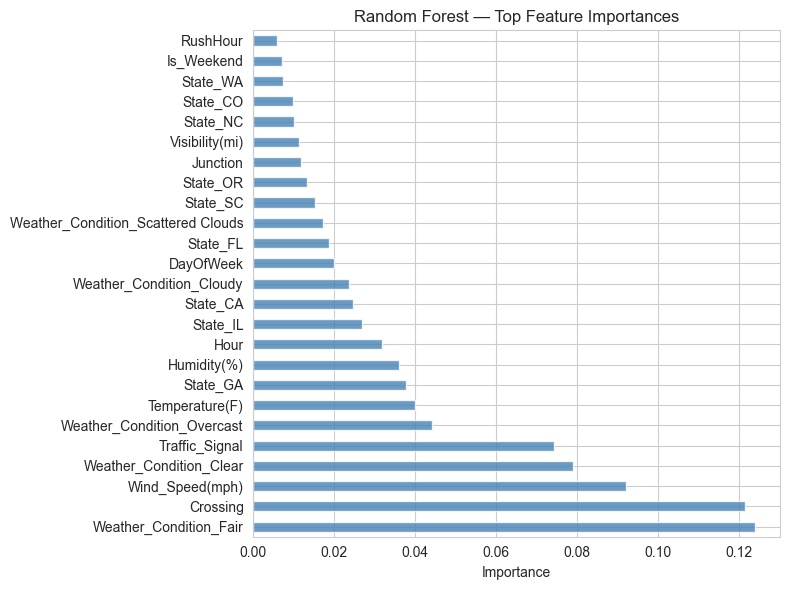

In [43]:
# Feature importance (Random Forest)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_n = min(25, len(imp))
imp.head(top_n).plot(kind="barh", figsize=(8, 6), color="steelblue", alpha=0.8)
plt.title("Random Forest — Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6.1 Improving model performance

**If metrics barely changed** after the new data pipeline (141 features, clipping, engineered features): the pipeline is in use. The main limit is **predictive signal**—severity depends on many unmeasured factors (impact speed, vehicle type, etc.), so gains from preprocessing alone are often small.

When trained models underperform on the positive class (High Severity), consider:

- **Threshold tuning:** Use precision–recall curves to choose a decision threshold that maximizes F1 for the positive class instead of the default 0.5.
- **Resampling:** SMOTE or other over/under-sampling on the training set to balance classes before training (e.g. with `imbalanced-learn`).
- **More data:** Use a larger sample or the full US Accidents dataset for more robust estimates.
- **Hyperparameter tuning:** Increase `n_iter` and/or CV folds in RandomizedSearchCV/GridSearchCV.
- **Features:** Add or engineer features (e.g. geographic clustering, time-of-day, weather interactions) if they are predictive.
- **Class weights:** Revisit `class_weight` / `scale_pos_weight` and ensure the scoring metric (e.g. F1 with `pos_label=1`) matches the business goal.

In [44]:
# Threshold tuning: find threshold that maximizes F1 for High Severity (positive class)
from sklearn.metrics import precision_recall_curve

y_proba_xgb = results_xgb["probabilities"]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb, pos_label=1)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last entry is undefined
best_threshold = thresholds[best_idx]
print(f"Best F1 (High) at threshold = {best_threshold:.4f}")

y_pred_tuned = (y_proba_xgb >= best_threshold).astype(int)
f1_high_tuned = f1_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
print(f"F1 (High) with default 0.5: {results_xgb.get('f1_high', 0):.4f}")
print(f"F1 (High) with tuned threshold: {f1_high_tuned:.4f}")

Best F1 (High) at threshold = 0.5523
F1 (High) with default 0.5: 0.4420
F1 (High) with tuned threshold: 0.4496


In [45]:
# Optional: SMOTE on training set, then retrain one model (e.g. Logistic Regression (baseline))
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    lr_smote = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    lr_smote.fit(X_train_resampled, y_train_resampled)
    y_pred_smote = lr_smote.predict(X_test_scaled)
    f1_high_smote = f1_score(y_test, y_pred_smote, pos_label=1, zero_division=0)
    print(f"LR with SMOTE — F1 (High): {f1_high_smote:.4f}")
except ImportError:
    print("SMOTE requires: pip install imbalanced-learn")

LR with SMOTE — F1 (High): 0.4350


In [46]:
# Stronger class weight: retrain XGBoost with 2x scale_pos_weight to predict more High severity
# (Increases recall for High; F1 may go up or down depending on precision trade-off.)
scale_pos_strong = 2.0 * (y_train == 0).sum() / max((y_train == 1).sum(), 1)
params = xgb_search.best_params_
xgb_strong = xgb.XGBClassifier(**params, random_state=42, scale_pos_weight=scale_pos_strong)
xgb_strong.fit(X_train_scaled, y_train)
y_pred_strong = xgb_strong.predict(X_test_scaled)
y_proba_strong = xgb_strong.predict_proba(X_test_scaled)[:, 1]
f1_high_strong = f1_score(y_test, y_pred_strong, pos_label=1, zero_division=0)
p_high, r_high, _, _ = precision_recall_fscore_support(y_test, y_pred_strong, average="binary", pos_label=1)
print("XGBoost with 2x scale_pos_weight:")
print(f"  F1 (High): {f1_high_strong:.4f}  Precision (High): {p_high:.4f}  Recall (High): {r_high:.4f}")
print(f"  Original XGBoost F1 (High): {results_xgb.get('f1_high', 0):.4f}")

XGBoost with 2x scale_pos_weight:
  F1 (High): 0.4005  Precision (High): 0.2589  Recall (High): 0.8845
  Original XGBoost F1 (High): 0.4420


## 7. Conclusions

- **Task:** We predicted binary **High_Severity** (Severity 3 or 4) using weather, time, infrastructure, and location (state) features from the US Accidents cleaned dataset.
- **Models:** Logistic Regression (baseline), Random Forest, XGBoost, DNN (MLP), and Stacking (LR+RF+XGB+DNN) were trained with class weighting to handle imbalance.
- **Evaluation:** Accuracy and ROC-AUC were used; the comparison table and confusion matrices show trade-offs between precision and recall for the minority (high-severity) class.
- **Next steps (optional):** Hyperparameter tuning (e.g. GridSearchCV), additional features (e.g. geographic clustering), or using the raw US_Accidents dataset with a larger sample for more robust estimates.